In [1]:
import seaborn as sns 
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split

In [2]:
data = sns.load_dataset("titanic")

In [3]:
data.sample(5)
data.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [4]:
# Setup :

features = ["pclass","sex","fare","embarked","age"]
target = ["survived"]

In [5]:
# Fill the missing values :

from sklearn.impute import SimpleImputer

med_imputer = SimpleImputer(strategy = "median")
data[["age"]] = med_imputer.fit_transform(data[["age"]])

freq_imputer = SimpleImputer(strategy = "most_frequent")
data[["embarked"]] = freq_imputer.fit_transform(data[["embarked"]])

In [6]:
data.isnull().sum()

survived         0
pclass           0
sex              0
age              0
sibsp            0
parch            0
fare             0
embarked         0
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [7]:
data

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,28.0,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [8]:
# Label Encoding :

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

data["sex"] = le.fit_transform(data["sex"])
data["embarked"] = le.fit_transform(data["embarked"])

In [9]:
# Split :

x = data[features]
y = data[target]

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.3,random_state=42)

In [11]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(x_test)

print("Accuracy : ",accuracy_score(y_test,y_pred))

Accuracy :  0.7798507462686567


Accuracy for dpeth =  2  :  0.7723880597014925
Accuracy for dpeth =  3  :  0.8059701492537313
Accuracy for dpeth =  4  :  0.8246268656716418


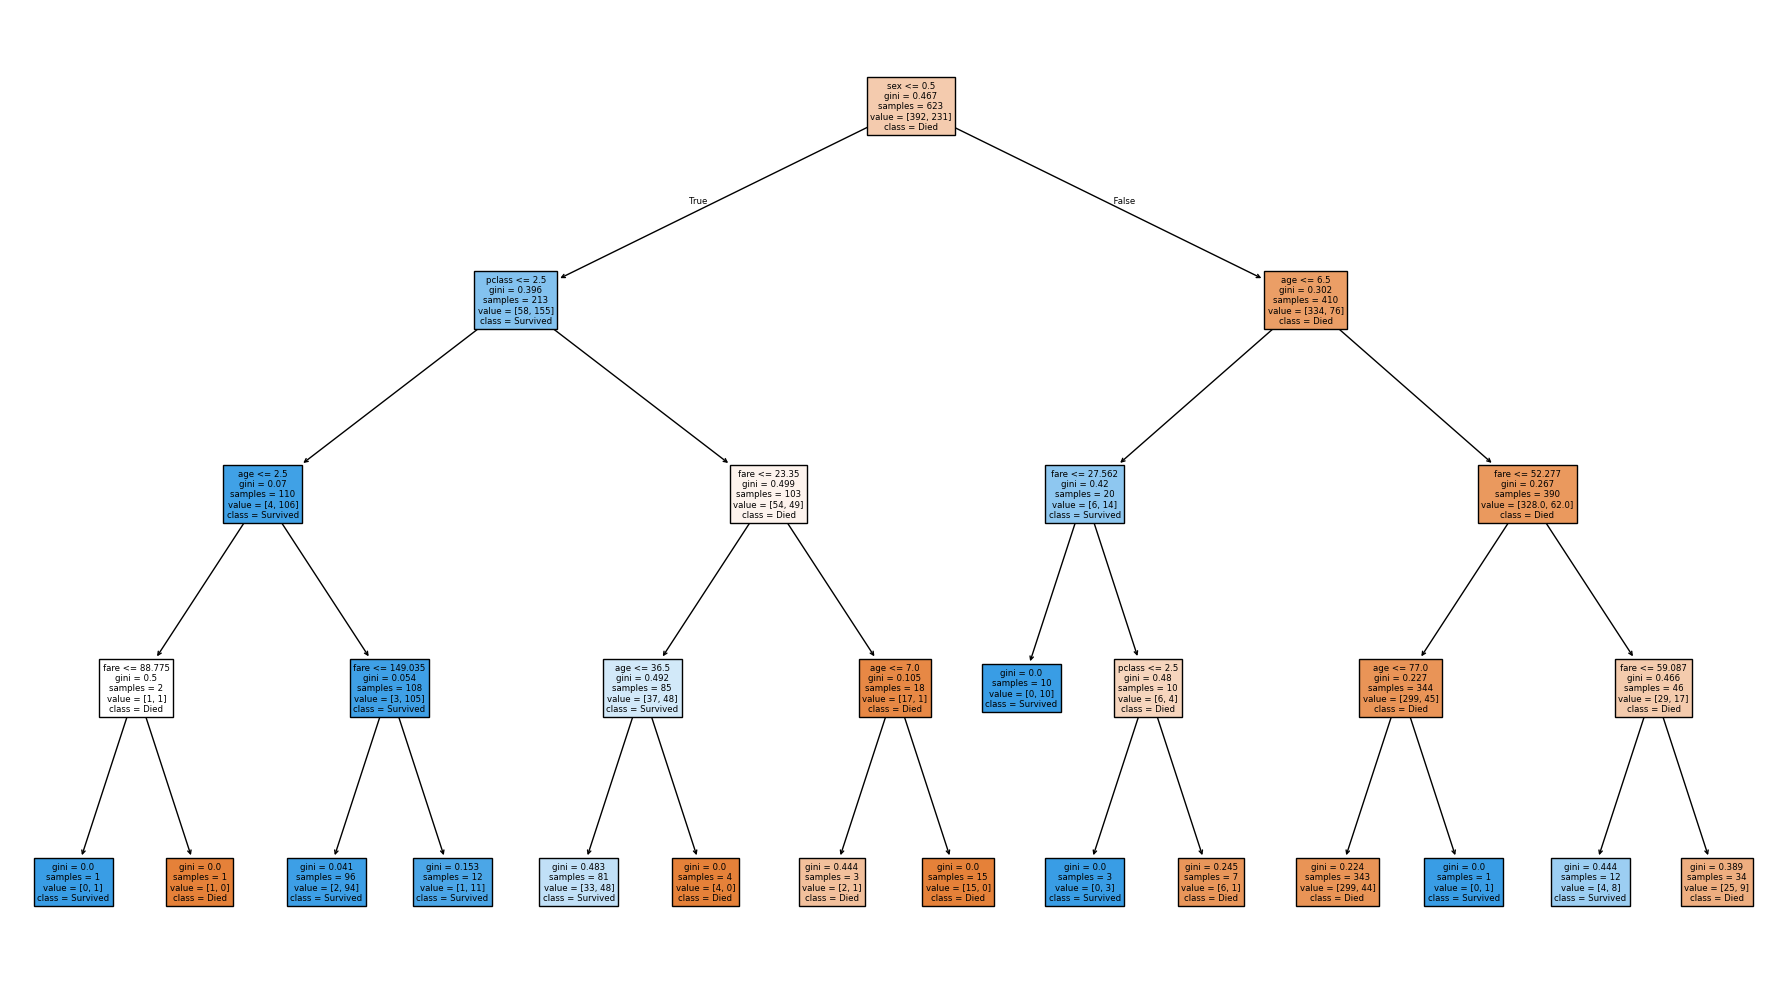

Accuracy for dpeth =  5  :  0.7985074626865671
Accuracy for dpeth =  6  :  0.7873134328358209
Accuracy for dpeth =  7  :  0.7798507462686567
Accuracy for dpeth =  8  :  0.7985074626865671
Accuracy for dpeth =  9  :  0.7649253731343284
Accuracy for dpeth =  10  :  0.7910447761194029


In [19]:
from sklearn.tree import plot_tree

depths = [2,3,4,5,6,7,8,9,10]

for depth in depths:
    model = DecisionTreeClassifier(random_state=42,max_depth=depth)
    model.fit(x_train,y_train)

    y_pred = model.predict(x_test)
    print("Accuracy for dpeth = ",depth," : ",accuracy_score(y_test,y_pred))

    if depth == 4:
        plt.figure(figsize=(18,10))
        plot_tree(
            model,
            feature_names = x.columns,
            class_names = ["Died","Survived"],
            filled = True,
            max_depth = 4
        )
        plt.tight_layout()
        plt.show()

Accuracy for min sample =  5  :  0.8246268656716418
Accuracy for min sample =  10  :  0.8246268656716418


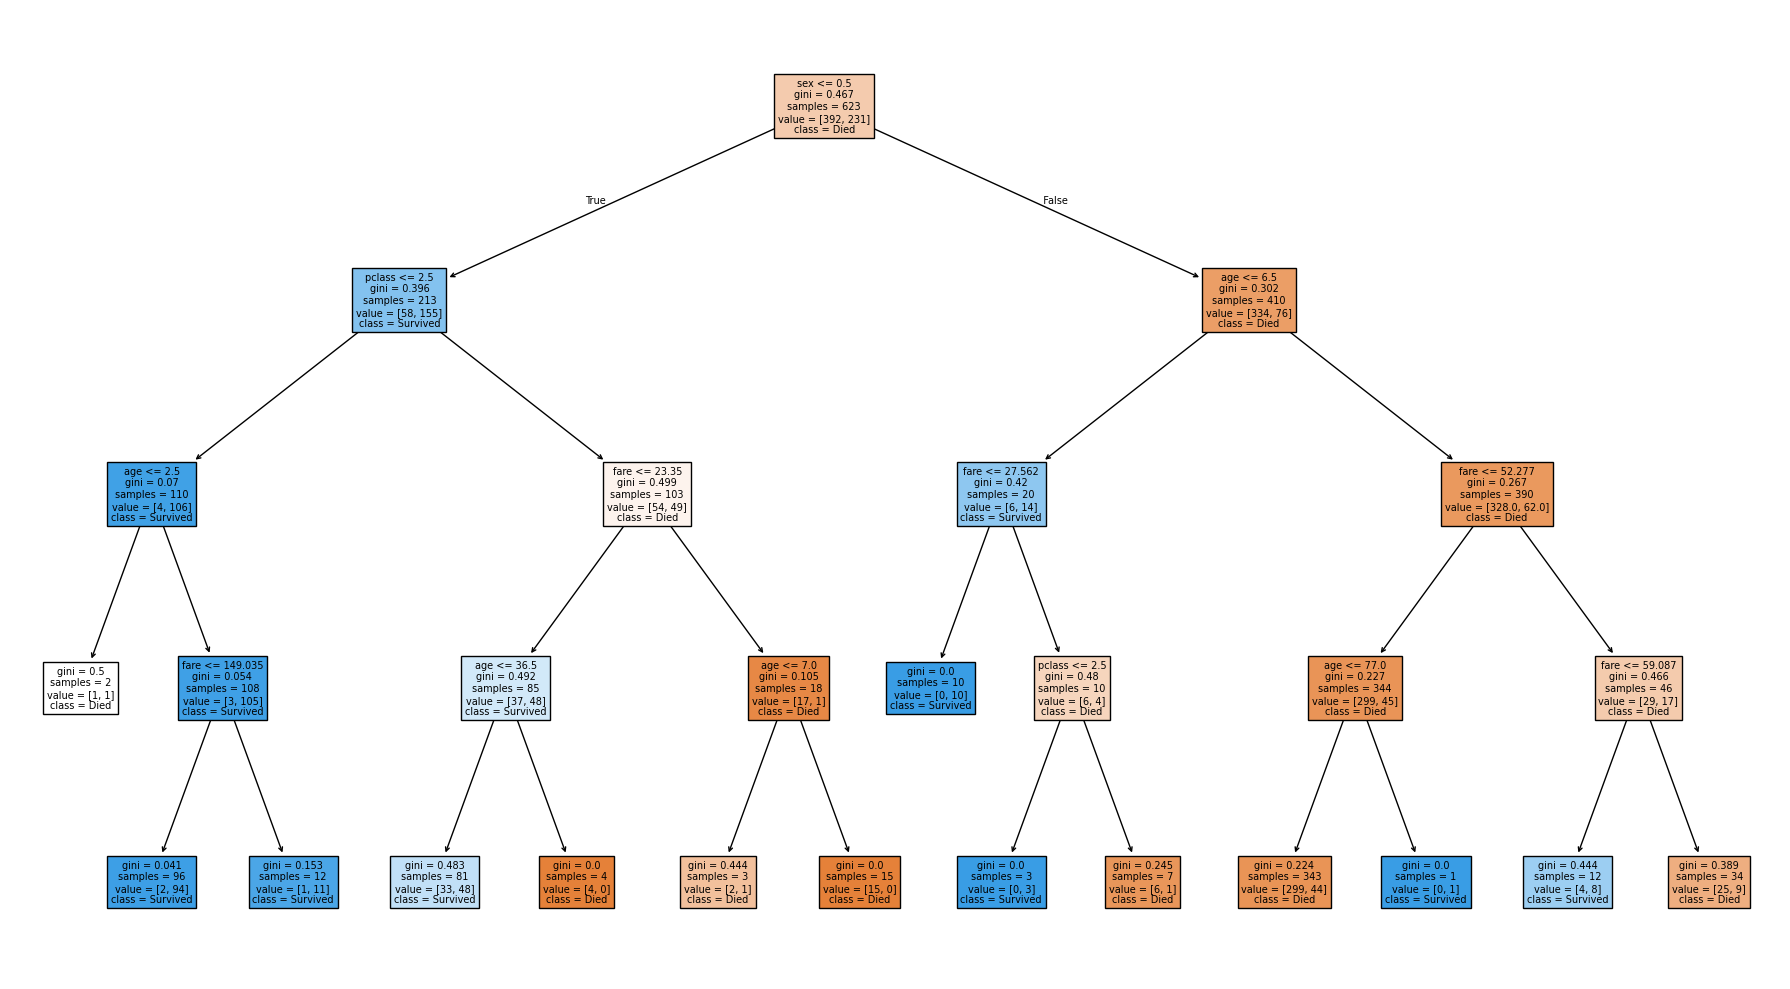

Accuracy for min sample =  15  :  0.8171641791044776
Accuracy for min sample =  20  :  0.8171641791044776
Accuracy for min sample =  25  :  0.8208955223880597
Accuracy for min sample =  30  :  0.8208955223880597
Accuracy for min sample =  35  :  0.8208955223880597
Accuracy for min sample =  40  :  0.8208955223880597
Accuracy for min sample =  45  :  0.8208955223880597
Accuracy for min sample =  50  :  0.8134328358208955


In [22]:
from sklearn.tree import plot_tree

samples = [5,10,15,20,25,30,35,40,45,50]

for sample in samples:
    model = DecisionTreeClassifier(random_state=42,max_depth=4,min_samples_split=sample)
    model.fit(x_train,y_train)

    y_pred = model.predict(x_test)
    print("Accuracy for min sample = ",sample," : ",accuracy_score(y_test,y_pred))

    if sample == 10:
        plt.figure(figsize=(18,10))
        plot_tree(
            model,
            feature_names = x.columns,
            class_names = ["Died","Survived"],
            filled = True,
            max_depth = 4,
        )
        plt.tight_layout()
        plt.show()